2025-01-30 13:53:26.995 | INFO     | trees.experiment:__init__:59 - Generating data: {'n': 100000, 'p': 10, 'sigma': 3.0, 'seed': 0, 'mode': 2}
2025-01-30 13:55:34.618 | INFO     | trees.experiment:__init__:66 - 	 [Pretrained] CF - Offline time: 0:02:07.518394
2025-01-30 13:55:34.619 | INFO     | trees.experiment:__init__:73 - 		 Generating P 1/10: {'min_s': 0.3, 'max_s': 0.95, 'features_in_P': 'all'}
2025-01-30 13:55:34.624 | DEBUG    | trees.data:generate_random_condition:107 - User condition: feature_4 > -0.642 AND feature_0 > -1.973, Selectivity: 0.72112
2025-01-30 13:55:34.625 | INFO     | trees.experiment:__init__:86 - 			 [Pretrained] CF - Online time: 0:00:00.000002
2025-01-30 13:55:35.544 | INFO     | trees.topk:scan:354 - Valid subgroups: 2660 out of 3768
  0%|          | 0/3921225 [00:00<?, ?it/s]2025-01-30 13:55:35.550 | INFO     | trees.topk:scan:363 - NEW score:0.89581640052457 previous: 0
2025-01-30 13:55:35.552 | INFO     | trees.topk:scan:363 - NEW score:0.946140919540

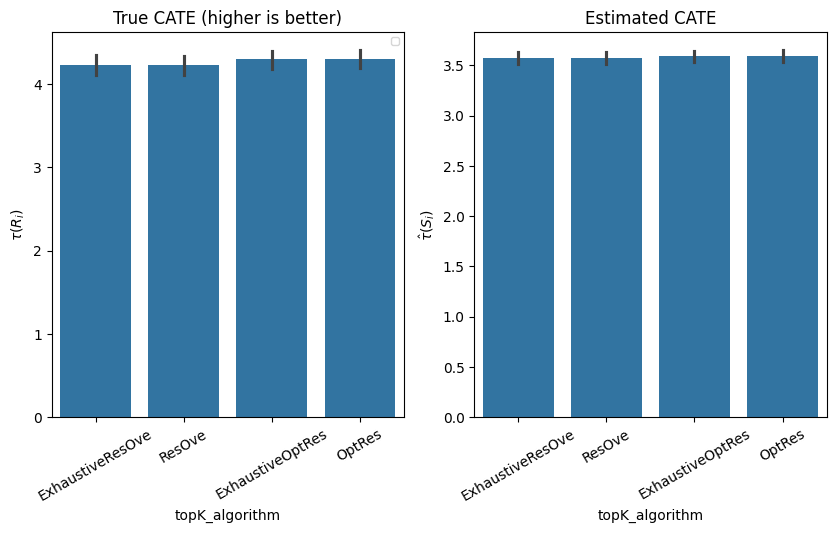

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


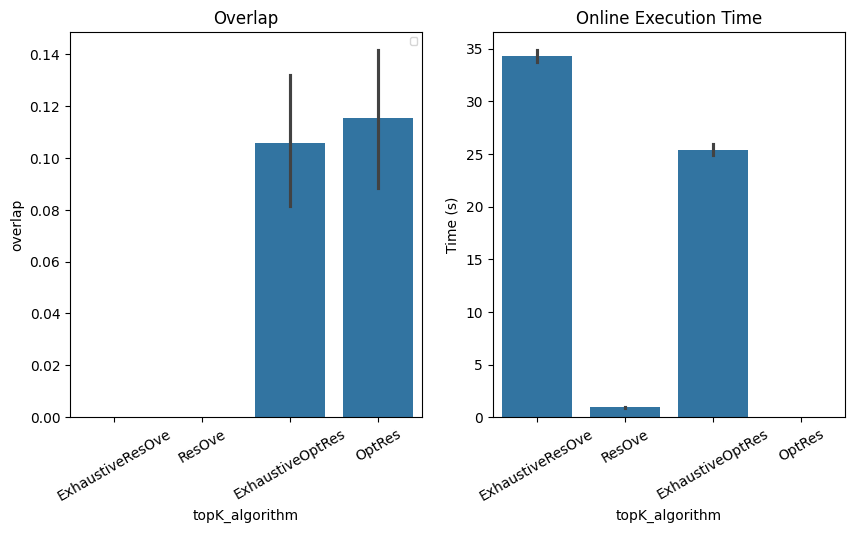

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


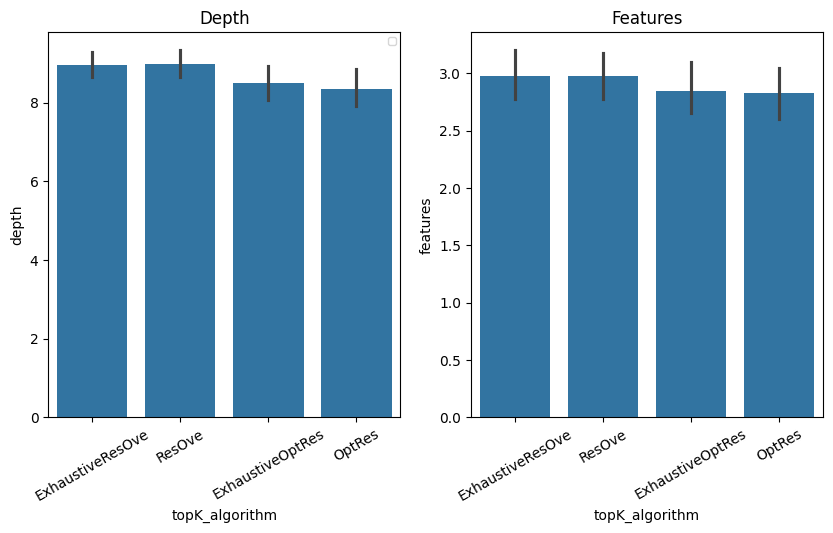

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


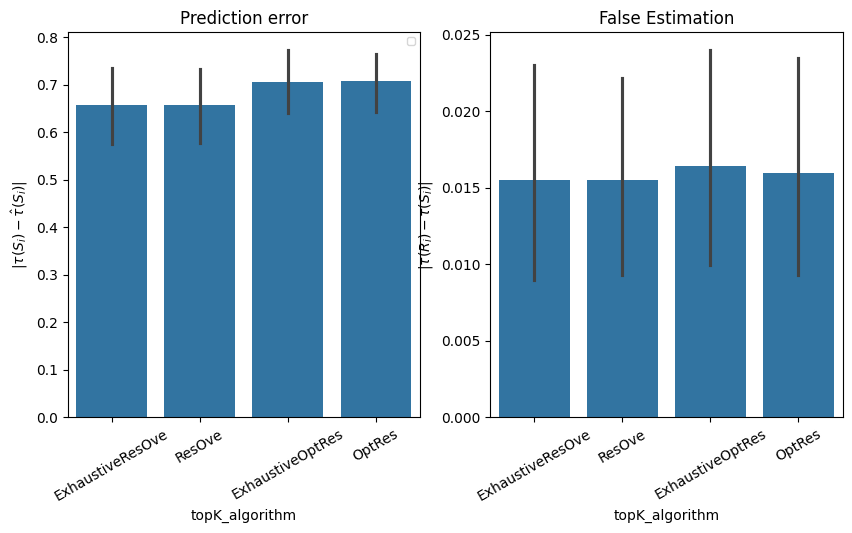

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


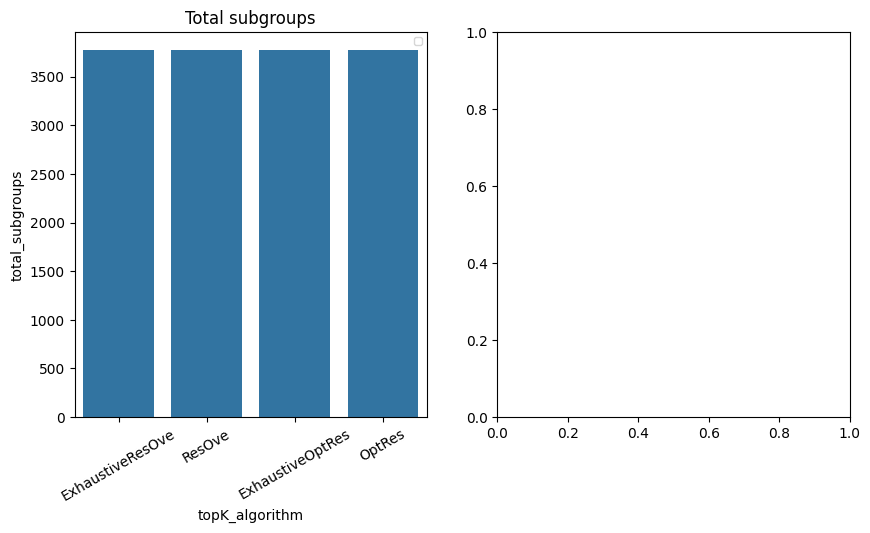

In [1]:
%load_ext autoreload
%autoreload 2
from trees.experiment import Experiment
from trees.topk import *
from trees.causal_forest import CFT
from trees.causal_tree import CT

top_k_methods = [ExhaustiveResOve, ResOve, ExhaustiveOptRes, OptRes]
exp = Experiment("topK_algorithm", exp_name="exhaustive", data_iterations=1, user_iterations=10, cate_models = [CFT],  topk_methods=top_k_methods)
exp.plot(hue=None)

In [15]:
s = exp.scores
CATE = s[s['topK_algorithm']=='OptRes']['t'].mean()/s[s['topK_algorithm']=='ExhaustiveOptRes']['t'].mean()
overlap = s[s['topK_algorithm']=='ExhaustiveOptRes']['overlap'].mean()/s[s['topK_algorithm']=='OptRes']['overlap'].mean()
print(f"OptRes % Exhaustive {CATE=}, {overlap=}")

OptRes % Exhaustive CATE=0.999848939087592, overlap=0.9168003189274598


In [14]:
CATE = s[s['topK_algorithm']=='ResOve']['t'].mean()/s[s['topK_algorithm']=='ExhaustiveResOve']['t'].mean()
print(f"ResOve % Exhaustive {CATE=}")

ResOve % Exhaustive CATE=0.9997281757639149
